#### Data Set

In [1]:
import random
import pandas as pd

# Set up storage for student metrics
records = []

# Generate synthetic dataset for 100 students
for student_id in range(1, 101):
    weekly_study_hrs = random.randint(5, 30)
    class_attendance_pct = random.randint(50, 100)
    joined_gd = random.choice(["Yes", "No"])
    last_test_score = random.randint(30, 100)
    outcome = random.choice(["Pass", "Fail"])

    records.append(
        {
            "Student_ID": student_id,
            "Study_Hours": weekly_study_hrs,
            "Attendance_Pct": class_attendance_pct,
            "Group_Discussion": joined_gd,
            "Previous_Score": last_test_score,
            "Final_Result": outcome,
        }
    )

# Build the dataset using Pandas
dataset = pd.DataFrame(records)

# Inspect sample records
print("Dataset Preview:")
print(dataset.head())

# Export dataset to CSV
output_filename = "student_performance_dataset.csv"
dataset.to_csv(output_filename, index=False)
print(f"Data saved to {output_filename}")

Dataset Preview:
   Student_ID  Study_Hours  Attendance_Pct Group_Discussion  Previous_Score  \
0           1            6              51               No              33   
1           2           15              53               No              36   
2           3            7              85              Yes              37   
3           4            7              64              Yes              97   
4           5           10              97              Yes              43   

  Final_Result  
0         Pass  
1         Pass  
2         Fail  
3         Pass  
4         Pass  
Data saved to student_performance_dataset.csv


# 1. Understanding the Basics

### What is Probability?

Probability is just a way to quantify how likely an event is to occur. It moves on a scale from **0** (completely impossible) to **1** (absolutely guaranteed).

---

### Core Terminology

* **Experiment:** Any process that produces an uncertain outcome.
* **Outcome:** The single result you get from a single trial.
* **Sample Space:** The entire collection of all possible outcomes.
* **Event:** A specific outcome or combination of outcomes you're looking at.

---

### Dataset Examples

1. Selecting a student who earned a `"Pass"` grade in their final result.
2. Spotting a student marked as `"Yes"` for group discussion involvement.
3. Picking a record where a student scored **above 80** on their previous internal test.

## 2. Types of Events

* Identify one **empirical probability** and one **theoretical probability** scenario from the dataset and Calculate both.

In [1]:
import pandas as pd

try:
    # Read the generated student records
    dataset = pd.read_csv("student_performance_dataset.csv")

    # 1. Empirical Probability: Based on real observations from our data
    total_records = len(dataset)
    fail_count = (dataset["Final_Result"] == "Fail").sum()
    empirical_p_fail = fail_count / total_records if total_records > 0 else 0

    print(
        f"Empirical Prob (Failing): {fail_count}/{total_records} = {empirical_p_fail:.2%}"
    )

    # 2. Theoretical Probability: Based on equal likelihood (Pass vs Fail)
    theoretical_p_fail = 1 / 2
    print(f"Theoretical Prob (Failing): 1/2 = {theoretical_p_fail:.2%}")

except FileNotFoundError:
    print("File missing: Please generate 'student_performance_dataset.csv' first.")
except KeyError:
    print("Column error: 'Final_Result' field missing in CSV.")

Empirical Prob (Failing): 43/100 = 43.00%
Theoretical Prob (Failing): 1/2 = 50.00%


### 3. Random Variable & Probability Distribution

    Define a random variable for the event "Number of students passing the final scenario" out of 3 randomly selected students.
    Find the mean and variance of this random variable.

In [2]:
import math
import pandas as pd

try:
    # Read the stored dataset
    dataset = pd.read_csv("student_performance_dataset.csv")

    # 1. Estimate Empirical Pass Probability (p)
    total_records = len(dataset)
    pass_count = (dataset["Final_Result"] == "Pass").sum()
    p_pass = pass_count / total_records if total_records > 0 else 0

    # 2. Setup Binomial Parameters (Selecting a sample of n = 3 students)
    sample_size = 3
    binomial_pmf = {}

    # 3. Calculate Binomial Probability Mass Function (PMF)
    # P(X = x) = C(n, x) * p^x * (1-p)^(n-x)
    for k_passes in range(sample_size + 1):
        combinations = math.comb(sample_size, k_passes)
        prob_k = (
            combinations
            * (p_pass**k_passes)
            * ((1 - p_pass) ** (sample_size - k_passes))
        )
        binomial_pmf[k_passes] = prob_k

    # 4. Calculate Expected Mean E[X] and Variance Var(X)
    expected_value = sample_size * p_pass
    variance = sample_size * p_pass * (1 - p_pass)

    # 5. Display Analytical Results
    print("--- Step 3: Binomial Distribution Analysis (n = 3) ---")
    print(
        f"Empirical Pass Probability (p): {pass_count}/{total_records} = {p_pass:.4f}\n"
    )

    print("Probability Mass Function (PMF):")
    for k_passes, prob in binomial_pmf.items():
        print(f"  P(X = {k_passes} passes) = {prob:.4f}")

    print(f"\nExpected Value E[X]: {expected_value:.4f}")
    print(f"Variance Var(X):     {variance:.4f}")

except FileNotFoundError:
    print(
        "File missing: Please run Step 1 to generate 'student_performance_dataset.csv'."
    )
except KeyError:
    print("Column error: 'Final_Result' field missing in CSV.")

--- Step 3: Binomial Distribution Analysis (n = 3) ---
Empirical Pass Probability (p): 57/100 = 0.5700

Probability Mass Function (PMF):
  P(X = 0 passes) = 0.0795
  P(X = 1 passes) = 0.3162
  P(X = 2 passes) = 0.4191
  P(X = 3 passes) = 0.1852

Expected Value E[X]: 1.7100
Variance Var(X):     0.7353



### 4. Venn Diagram in Probability
   - Draw a Venn diagram showing:
     - Students who study more than 10 hours/week.
     - Students who attend more than 80% of classes.
     - Overlap showing students who satisfy both conditions.


High Study Time Only: 46
High Attendance Only: 12
Satisfies Both: 29
Satisfies Neither: 13


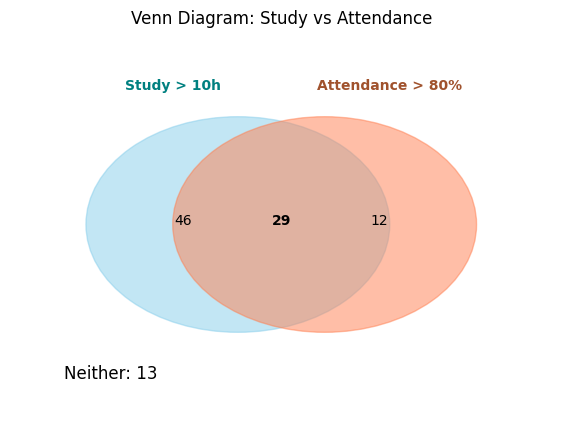

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import pandas as pd

# Load dataset
records = pd.read_csv("student_performance_dataset.csv")

# Identify condition filters
high_study_time = records["Study_Hours"] > 10
high_attendance_rate = records["Attendance_Pct"] > 80

# Calculate subset counts
only_study = (high_study_time & ~high_attendance_rate).sum()
only_attendance = (~high_study_time & high_attendance_rate).sum()
both_criteria = (high_study_time & high_attendance_rate).sum()
outside_both = (~high_study_time & ~high_attendance_rate).sum()

print(f"High Study Time Only: {only_study}")
print(f"High Attendance Only: {only_attendance}")
print(f"Satisfies Both: {both_criteria}")
print(f"Satisfies Neither: {outside_both}")

# Venn Diagram
fig, ax = plt.subplots(figsize=(7, 5))
ax.add_patch(Circle((0.42, 0.5), 0.28, color="skyblue", alpha=0.5))
ax.add_patch(Circle((0.58, 0.5), 0.28, color="coral", alpha=0.5))

ax.text(0.32, 0.5, str(only_study), ha="center")
ax.text(0.68, 0.5, str(only_attendance), ha="center")
ax.text(0.50, 0.5, str(both_criteria), ha="center", weight="bold")
ax.text(0.1, 0.1, f"Neither: {outside_both}", fontsize=12)

ax.text(0.3, 0.85, "Study > 10h", ha="center", color="teal", weight="bold")
ax.text(0.7, 0.85, "Attendance > 80%", ha="center", color="sienna", weight="bold")
ax.set_title("Venn Diagram: Study vs Attendance")
ax.axis("off")
plt.show()


### 5. Contingency Table & Probability Calculations
   - Create a contingency table for group_discussion (Yes/No) vs. final_exam_pass (Pass/Fail).
   - From the table, calculate:
     - Joint probability of "Participates in group discussion AND Passes exam".
     - Marginal probability of "Passes exam".
     - Conditional probability of "Passes exam given participation in group discussion".


In [6]:
import pandas as pd

# Load dataset
df = pd.read_csv("student_performance_dataset.csv")

# Contingency table
ct = pd.crosstab(df["Group_Discussion"], df["Final_Result"])
print(ct)

total = len(df)

# Joint probability: GD = Yes & Result = Pass
joint_cnt = len(df[(df["Group_Discussion"] == "Yes") & (df["Final_Result"] == "Pass")])
p_joint = joint_cnt / total

# Marginal probability: Result = Pass
pass_cnt = (df["Final_Result"] == "Pass").sum()
p_pass = pass_cnt / total

# Conditional probability: Pass given GD = Yes
gd_cnt = (df["Group_Discussion"] == "Yes").sum()
p_cond = joint_cnt / gd_cnt if gd_cnt > 0 else 0

print("Joint Prob (GD & Pass):", p_joint)
print("Marginal Prob (Pass):", p_pass)
print("Conditional Prob (Pass | GD):", p_cond)

Final_Result      Fail  Pass
Group_Discussion            
No                  16    27
Yes                 27    30
Joint Prob (GD & Pass): 0.3
Marginal Prob (Pass): 0.57
Conditional Prob (Pass | GD): 0.5263157894736842


### 6. Understanding Relationships
* Interpret conditional probability results in plain language ("intuition" behind formula).
* Identify if "participating in group discussions" and "passing exam" are independent, dependent, or mutually exclusive events. Justify your answer.


In [7]:
import pandas as pd

df = pd.read_csv("student_performance_dataset.csv")

# Overall pass probability
p_pass = (df["Final_Result"] == "Pass").mean()

# Pass probability for GD participants
gd_df = df[df["Group_Discussion"] == "Yes"]
p_pass_gd = (gd_df["Final_Result"] == "Pass").mean()

print(f"Overall Pass Prob: {p_pass:.2f}")
print(f"Pass Prob given GD: {p_pass_gd:.2f}\n")

print("Interpretation:")
print(f"Overall pass rate is {p_pass:.2%}.")
print(f"Pass rate among GD participants is {p_pass_gd:.2%}.")
print("Joining GD shifts the pass likelihood.")

# Dependence check
if p_pass_gd == p_pass:
    print("Events are independent.")
else:
    print("Events are dependent because probabilities differ.")

# Mutually exclusive check
both_cnt = ((df["Group_Discussion"] == "Yes") & (df["Final_Result"] == "Pass")).sum()
if both_cnt == 0:
    print("Events are mutually exclusive.")
else:
    print("Events are not mutually exclusive since students can do both.")

print("\nIntuition: Conditional probability updates pass odds once GD status is known.")

Overall Pass Prob: 0.57
Pass Prob given GD: 0.53

Interpretation:
Overall pass rate is 57.00%.
Pass rate among GD participants is 52.63%.
Joining GD shifts the pass likelihood.
Events are dependent because probabilities differ.
Events are not mutually exclusive since students can do both.

Intuition: Conditional probability updates pass odds once GD status is known.


### 7. Bayes Theorem Application

*   **Scenario:** Suppose historical data shows:
    *   70% of students who pass had high attendance (>80%).
    *   40% of students who fail also had high attendance.
    *   60% of all students had high attendance.
    *   **Question:** Use Bayes Theorem to find the probability that a student passed the exam given they had high attendance.

In [8]:
# Given values
p_high_given_pass = 0.70
p_high_given_fail = 0.40
p_high = 0.60

# Solve for overall P(Pass) using Law of Total Probability
p_pass = (p_high - p_high_given_fail) / (p_high_given_pass - p_high_given_fail)

# Apply Bayes' Theorem: P(Pass | High)
p_pass_given_high = (p_high_given_pass * p_pass) / p_high

print("P(Pass):", round(p_pass, 4))
print("P(Pass | High Attendance):", round(p_pass_given_high, 4))
print(f"Percentage: {p_pass_given_high:.2%}")

P(Pass): 0.6667
P(Pass | High Attendance): 0.7778
Percentage: 77.78%
